In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

In [ ]:
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)
csv_path = zip_path.replace(".zip", "")
df = pd.read_csv(csv_path)

In [ ]:
df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420546,31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
420547,31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
420548,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420549,31.12.2016 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8


In [ ]:
df.columns

Index(['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
       'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)'],
      dtype='object')

In [ ]:
df.dtypes

Date Time           object
p (mbar)           float64
T (degC)           float64
Tpot (K)           float64
Tdew (degC)        float64
rh (%)             float64
VPmax (mbar)       float64
VPact (mbar)       float64
VPdef (mbar)       float64
sh (g/kg)          float64
H2OC (mmol/mol)    float64
rho (g/m**3)       float64
wv (m/s)           float64
max. wv (m/s)      float64
wd (deg)           float64
dtype: object

In [ ]:
df.isna().sum()

Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

In [ ]:
df = df[5::6]

date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')


wv = df['wv (m/s)']
wv[wv == -9999.0] = 0.0

wd_rad = df.pop('wd (deg)')*np.pi / 180
df['Wx'] = wv * np.cos(wd_rad)
df['Wy'] = wv * np.sin(wd_rad)

In [ ]:

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

# Prepare the input and target data for the model
sequence_length = 168  # Example: use the past week of data (24*7 hours)
X = []
y = []

In [ ]:
for i in range(len(df_scaled) - sequence_length):
    X.append(df_scaled[i:i+sequence_length])
    y.append(df_scaled[i+sequence_length, 0])

X = np.array(X)
y = np.array(y)

train_size = int(len(X) * 0.8)


NameError: name 'df_scaled' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, Input, ReLU, Add, Dropout, Dense, Lambda
from tensorflow.keras.models import Model

def TemporalBlock(x, n_outputs, kernel_size, stride, dilation_rate, padding, dropout):
    conv1 = Conv1D(filters=n_outputs, kernel_size=kernel_size, strides=stride, padding=padding, dilation_rate=dilation_rate)(x)
    conv1 = ReLU()(conv1)
    conv1 = Dropout(dropout)(conv1)

    conv2 = Conv1D(filters=n_outputs, kernel_size=kernel_size, strides=stride, padding=padding, dilation_rate=dilation_rate)(conv1)
    conv2 = ReLU()(conv2)
    conv2 = Dropout(dropout)(conv2)

    if x.shape[-1] != n_outputs:
        x = Conv1D(filters=n_outputs, kernel_size=1, padding='same')(x)

    out = Add()([conv2, x])
    return ReLU()(out)

In [ ]:
def TemporalConvNet(input_shape, num_channels, kernel_size=2, dropout=0.2):
    inputs = Input(shape=input_shape)
    x = inputs

    for i in range(len(num_channels)):
        dilation_rate = 2 ** i
        x = TemporalBlock(x, num_channels[i], kernel_size, stride=1, dilation_rate=dilation_rate, padding='causal', dropout=dropout)

    model = Model(inputs=inputs, outputs=x)
    return model

In [ ]:
def TCMix(input_shape, num_channels, output_size, kernel_size=2, dropout=0.2):
    tcn = TemporalConvNet(input_shape, num_channels, kernel_size, dropout)
    inputs = Input(shape=input_shape)
    x = tcn(inputs)
    x = Lambda(lambda x: x[:, -1, :])(x)  # Use the last output of the sequence
    outputs = Dense(output_size)(x)
    model = Model(inputs=inputs, outputs=outputs)
    return model

In [ ]:
input_shape = (sequence_length, df_scaled.shape[1])  # (sequence length, input size)
output_size = 1  # Predicting a single value (temperature)
num_channels = [25, 50, 100]  # Example channel sizes for TCN layers
kernel_size = 2
dropout = 0.2

In [ ]:
model = TCMix(input_shape, num_channels, output_size, kernel_size, dropout)
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 168, 15)]         0         
                                                                 
 model (Functional)          (None, 168, 100)          46650     
                                                                 
 lambda (Lambda)             (None, 100)               0         
                                                                 
 dense (Dense)               (None, 1)                 101       
                                                                 
Total params: 46751 (182.62 KB)
Trainable params: 46751 (182.62 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
1399/1399 [==============================] - 22s 9ms/step - loss: 0.0060 - val_loss: 2.3152e-04
Epoch 2/20
1399/1399 [==============================] - 12s 8ms/step - loss: 1.3136e-04 - val_loss: 2.9390e-05
Epoch 3/20
1399/1399 [==============================] - 11s 8ms/step - loss: 5.4616e-05 - val_loss: 2.2664e-05
Epoch 4/20
1399/1399 [==============================] - 11s 8ms/step - loss: 5.4749e-05 - val_loss: 2.0522e-05
Epoch 5/20
1399/1399 [==============================] - 12s 8ms/step - loss: 4.7751e-05 - val_loss: 2.3043e-05
Epoch 6/20
1399/1399 [==============================] - 12s 8ms/step - loss: 5.2291e-05 - val_loss: 2.9876e-05
Epoch 7/20
1399/1399 [==============================] - 12s 8ms/step - loss: 4.0739e-05 - val_loss: 2.9589e-05
Epoch 8/20
1399/1399 [==============================] - 12s 8ms/step - loss: 4.2920e-05 - val_loss: 4.9897e-05
Epoch 9/20
1399/1399 [==============================] - 12s 8ms/step - loss: 4.4912e-05 - val_loss: 2.5302e-05
Epoch

In [ ]:

test_loss = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss}')




438/438 [==============================] - 2s 4ms/step - loss: 2.9164e-05
Test Loss: 2.9164393708924763e-05


In [ ]:

y_pred = model.predict(X_test)
y_pred



438/438 [==============================] - 1s 3ms/step


array([[0.7296489 ],
       [0.73414737],
       [0.73811316],
       ...,
       [0.8593533 ],
       [0.857024  ],
       [0.8521906 ]], dtype=float32)

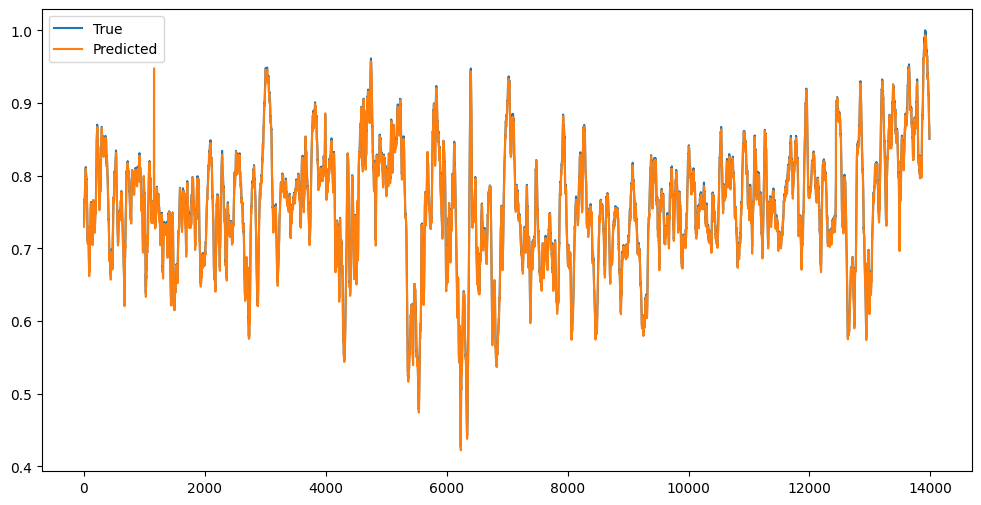

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='True')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()